In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import json

In [ ]:
with open ('../../data/raw_concat/tobacco.json', 'r', encoding='utf-8') as f:
    data = json.load(f)
df = pd.DataFrame(data)
print(df.head())

  ParentLocationCode SpatialDim      Dim1             Value  NumericValue  \
0                EMR        EGY  SEX_FMLE     0.3 [0.2-0.5]           0.3   
1                EUR        DEU  SEX_FMLE  13.8 [11.1-16.6]          13.8   
2                AFR        MUS  SEX_FMLE     2.0 [1.2-2.8]           2.0   
3                EUR        ISR   SEX_MLE  30.9 [25.8-36.0]          30.9   
4                EUR        MKD   SEX_MLE  54.0 [32.8-75.3]          54.0   

                            Date   IndicatorCode  
0  2026-01-15T18:34:46.917+01:00  M_Est_cig_curr  
1  2026-01-15T18:34:46.917+01:00  M_Est_cig_curr  
2  2026-01-15T18:34:46.917+01:00  M_Est_cig_curr  
3  2026-01-15T18:34:46.917+01:00  M_Est_cig_curr  
4  2026-01-15T18:34:46.917+01:00  M_Est_cig_curr  


In [24]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 48540 entries, 0 to 48539
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ParentLocationCode  48276 non-null  str    
 1   SpatialDim          48540 non-null  str    
 2   Dim1                48540 non-null  str    
 3   Value               48540 non-null  str    
 4   NumericValue        46887 non-null  float64
 5   Date                48540 non-null  str    
 6   IndicatorCode       48540 non-null  str    
dtypes: float64(1), str(6)
memory usage: 2.6 MB


,NumericValue
count,46887.000000
mean,35.251462
std,584.461042
min,0.000000
25%,4.000000
50%,10.400000
75%,24.800000
max,46010.000000


In [25]:
df['NumericValue'].isnull().sum()

np.int64(1653)

In [26]:
# remove null value
print(len(df))
df=df.dropna(subset=['NumericValue'])
print(len(df))
print(df["NumericValue"].isnull().sum())

48540
46887
0


In [27]:
some_code = 'TOBACCO_MPOWER_M4_SMOKELESSECIGARETTESSCHOOL'
df_test = df[df['IndicatorCode'] == some_code]
print(df_test.head())

      ParentLocationCode SpatialDim                                    Dim1  \
33334               SEAR        MDV  TOBACCO_INDICATOR_Yth_nonsmoked_svy_yr   
33340                AFR        ETH  TOBACCO_INDICATOR_Yth_nonsmoked_svy_yr   
33343                WPR        VUT  TOBACCO_INDICATOR_Yth_nonsmoked_svy_yr   
33351                AFR        COG  TOBACCO_INDICATOR_Yth_nonsmoked_svy_yr   
33360                EMR        PAK  TOBACCO_INDICATOR_Yth_nonsmoked_svy_yr   

      Value  NumericValue                          Date  \
33334  2019        2019.0  2025-07-24T14:32:31.79+02:00   
33340  2023        2023.0  2025-07-24T14:32:31.79+02:00   
33343  2017        2017.0  2025-07-24T14:32:31.79+02:00   
33351  2019        2019.0  2025-07-24T14:32:31.79+02:00   
33360  2013        2013.0  2025-07-24T14:32:31.79+02:00   

                                      IndicatorCode  
33334  TOBACCO_MPOWER_M4_SMOKELESSECIGARETTESSCHOOL  
33340  TOBACCO_MPOWER_M4_SMOKELESSECIGARETTESSCHOOL  
33343  T

In [28]:
# #remove indicators that not relevant
unrelated = set(['TOBACCO_MPOWER_M4_SMOKELESSECIGARETTESSCHOOL'])
df = df[~df['IndicatorCode'].isin(unrelated)]

In [29]:
indicators = df['IndicatorCode'].unique().tolist()
print(indicators)

['M_Est_cig_curr', 'M_Est_cig_curr_std', 'M_Est_smk_curr', 'M_Est_smk_curr_std', 'M_Est_tob_curr', 'M_Est_tob_curr_std', 'TOBACCO_MPOWER_OVERVIEW']


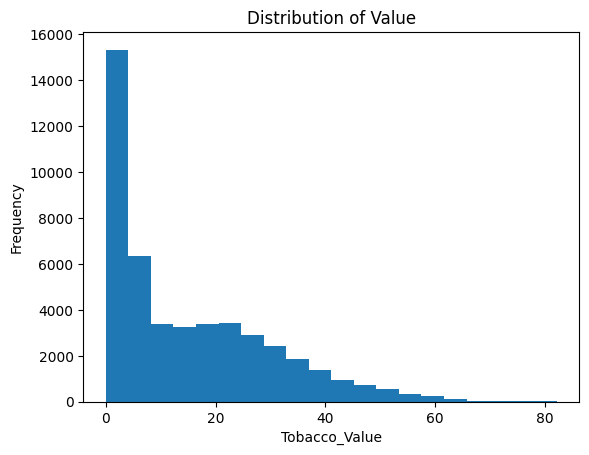

In [30]:
plt.figure()
plt.hist(df["NumericValue"], bins=20)
plt.xlabel("Tobacco_Value")
plt.ylabel("Frequency")
plt.title("Distribution of Value")
plt.show()


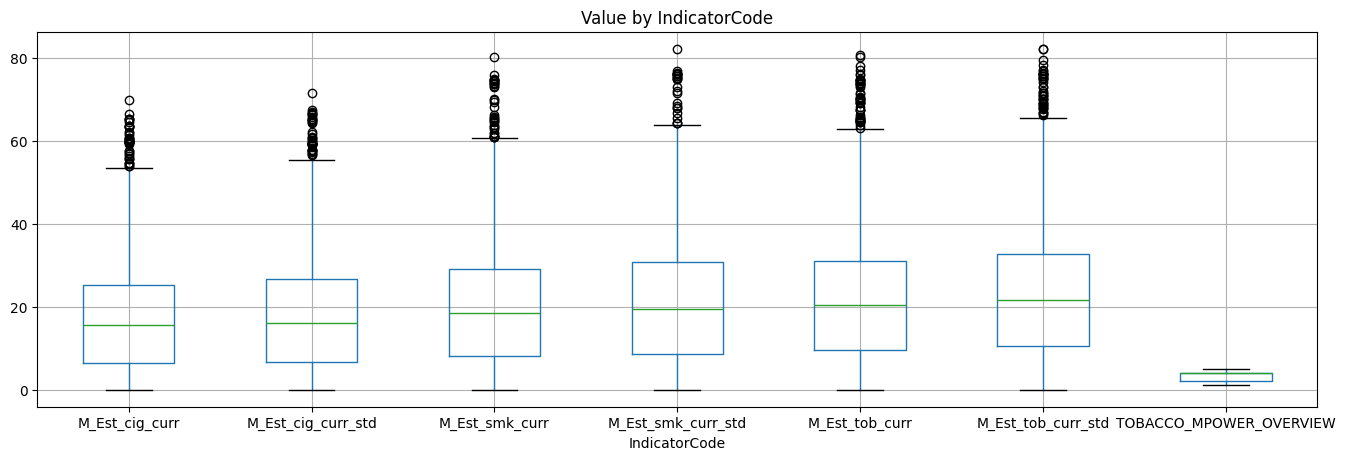

In [31]:
fig, ax = plt.subplots(figsize=(16,5))
df.boxplot(column="NumericValue", by="IndicatorCode", ax=ax)

ax.set_title("Value by IndicatorCode")
plt.suptitle("")
plt.show()